# 03 — Análisis de Efectos Secundarios por Componentes

Este notebook ejecuta el pipeline completo de análisis y validación
para el Enfoque 3: Efectos Secundarios por Componentes.

Genera las siguientes visualizaciones:
1. Top efectos secundarios globales
2. Componentes con mayor diversidad de efectos
3. Heatmap normalizado componente × efecto
4. Boxplot de efectos por número de componentes
5. Detalle de top efectos por componente
6. Histograma de distribución de n_efectos

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.load_data import load_medicine_data
from src.enfoque_03_efectos_secundarios_componentes.cleaning import run_cleaning_pipeline
from src.enfoque_03_efectos_secundarios_componentes.transform import run_transform_pipeline
from src.enfoque_03_efectos_secundarios_componentes.analysis import run_analysis_pipeline
from src.enfoque_03_efectos_secundarios_componentes.validation import run_validation_pipeline

from src.enfoque_03_efectos_secundarios_componentes.analysis import (
    plot_top_efectos,
    plot_componentes_por_diversidad_efectos,
    plot_heatmap_componente_efecto,
    plot_efectos_por_n_componentes,
    plot_top_efectos_por_componente,
    plot_histograma_n_efectos,
)

# 1. Cargar datos raw
df_raw = load_medicine_data(download_if_missing=True)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

# 2. Limpieza
df_clean = run_cleaning_pipeline(df_raw, save=False)

# 3. Transformaciones
df_long, crosstab, crosstab_norm = run_transform_pipeline(
    df_clean, min_observaciones=5, top_n_efectos=30, save=False
)

Dataset cargado: 11,825 filas × 9 columnas
INICIO DEL PIPELINE DE LIMPIEZA  [Enfoque 3]
[eliminar_duplicados] Filas antes: 11825 | Eliminados: 84 | Filas después: 11741
[añadir_columnas_derivadas] Columnas generadas: componentes, efectos_secundarios, manufacturer, n_componentes, n_efectos
[añadir_columnas_derivadas] Distribución por número de componentes:
    1 componente(s)  ->  7019 medicamentos
    2 componente(s)  ->  3569 medicamentos
    3 componente(s)  ->   929 medicamentos
    4 componente(s)  ->   147 medicamentos
    5 componente(s)  ->    51 medicamentos
    6 componente(s)  ->    16 medicamentos
    7 componente(s)  ->     7 medicamentos
    8 componente(s)  ->     2 medicamentos
    9 componente(s)  ->     1 medicamentos
[flag_anomalias] Registros sin componentes: 0
[flag_anomalias] Registros sin efectos secundarios: 0
-------------------------------------------------------
Forma final del DataFrame: (11741, 16)
INICIO DEL PIPELINE DE TRANSFORMACIONES  [Enfoque 3]
[explot

In [2]:
# 4. Validación de integridad
reporte = run_validation_pipeline(df_raw, df_clean)
print(f"\nEsquema válido: {reporte['esquema']['esquema_valido']}")
print(f"Filas eliminadas en limpieza: {reporte['shapes']['filas_eliminadas']}")

INICIO DEL PIPELINE DE VALIDACIÓN  [Enfoque 3]

[1/4] Verificando checksum MD5...
[verificar_checksum] Medicine_Details.csv
    MD5     : 93656e73e4e8fbf7dd8da9ecfab7ce07
    Tamaño  : 4,360,239 bytes
    Estado  : SIN_REFERENCIA

[2/4] Validando esquema del DataFrame raw...
[validar_esquema] Estado: INVÁLIDO
    Tipos incorrectos   : {'Medicine Name': {'esperado': 'object', 'real': 'str'}, 'Composition': {'esperado': 'object', 'real': 'str'}, 'Uses': {'esperado': 'object', 'real': 'str'}, 'Side_effects': {'esperado': 'object', 'real': 'str'}, 'Image URL': {'esperado': 'object', 'real': 'str'}, 'Manufacturer': {'esperado': 'object', 'real': 'str'}}

[3/4] Comparando shapes antes/después de limpieza...
[comparar_shapes]
    Filas raw           : 11,825
    Filas limpias       : 11,741
    Filas eliminadas    : 84 (0.71%)
    Columnas raw        : 9
    Columnas clean      : 16
    Columnas nuevas     : ['anomalia_componentes', 'anomalia_efectos', 'componentes', 'efectos_secundarios', 'm

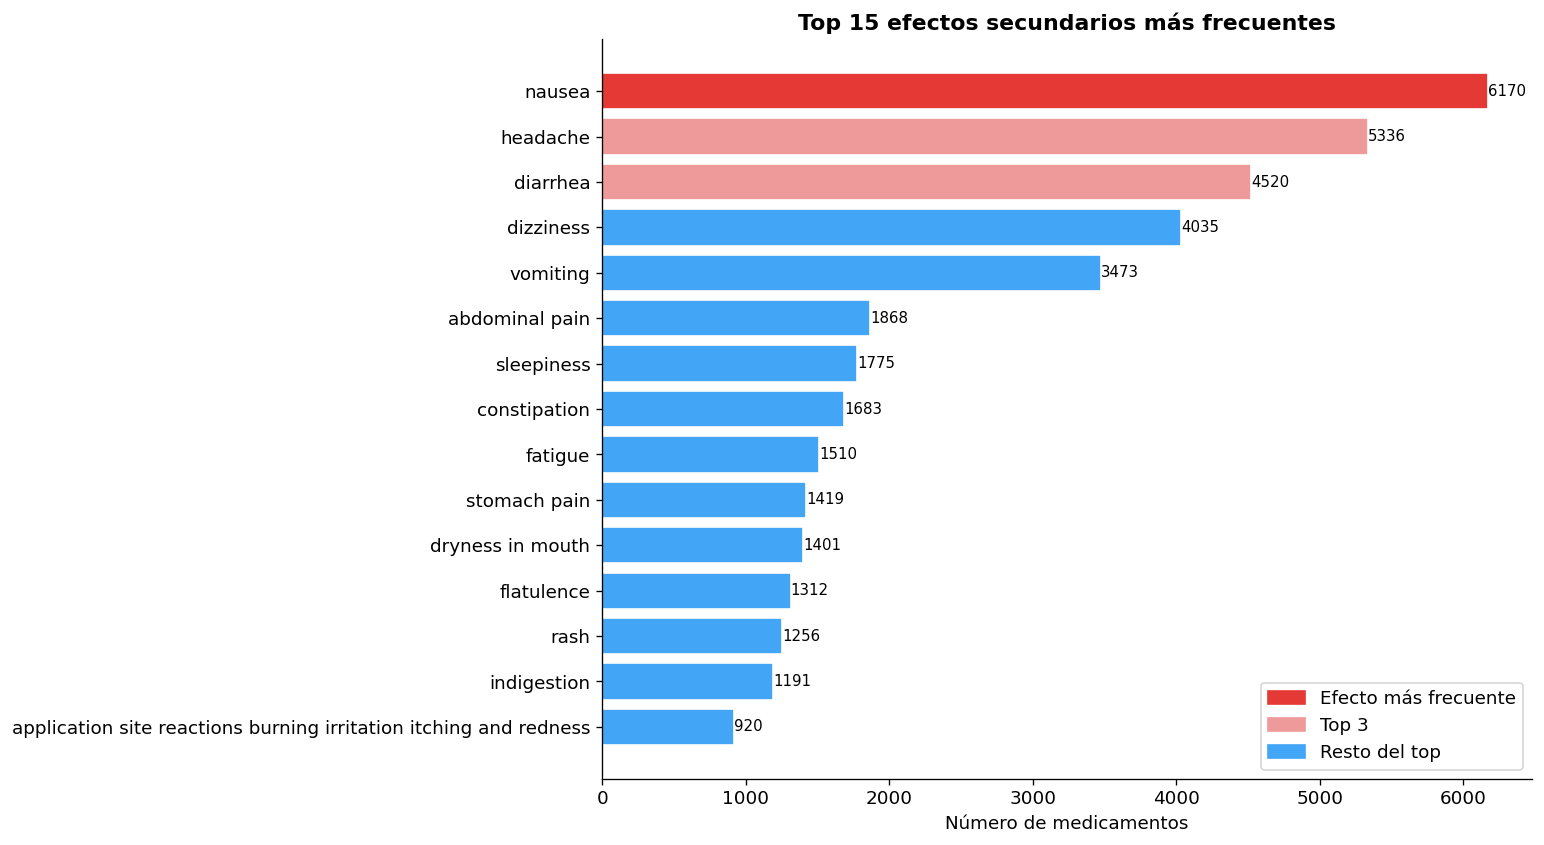

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_top_efectos_globales.png
[analysis] Tabla guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/tables/e03_top_efectos_globales.csv


,efecto,frecuencia
0,nausea,6170
1,headache,5336
2,diarrhea,4520
3,dizziness,4035
4,vomiting,3473
5,abdominal pain,1868
6,sleepiness,1775
7,constipation,1683
8,fatigue,1510
9,stomach pain,1419


In [3]:
# 5.1 Top efectos secundarios globales
plot_top_efectos(df_clean, top_n=15)

— Top 15 efectos secundarios más frecuentes
El análisis del ranking global revela que los efectos gastrointestinales y neurológicos leves dominan el panorama de reacciones adversas del dataset. Nausea encabeza la distribución apareciendo en 6.170 medicamentos (≈52% del total de 11.825 registros), seguida de headache con 5.336 ocurrencias (≈45%) y diarrhea con 4.520 (≈38%). Estos tres efectos concentran una proporción desproporcionadamente alta respecto al resto del top, marcando una clara caída hacia efectos como dizziness (4.035) y vomiting (3.473).
Este patrón sugiere que más de la mitad de los medicamentos catalogados comparten un perfil de tolerabilidad similar, lo que resulta consistente con la literatura farmacológica: náusea y cefalea son reacciones inespecíficas asociadas a múltiples familias terapéuticas.

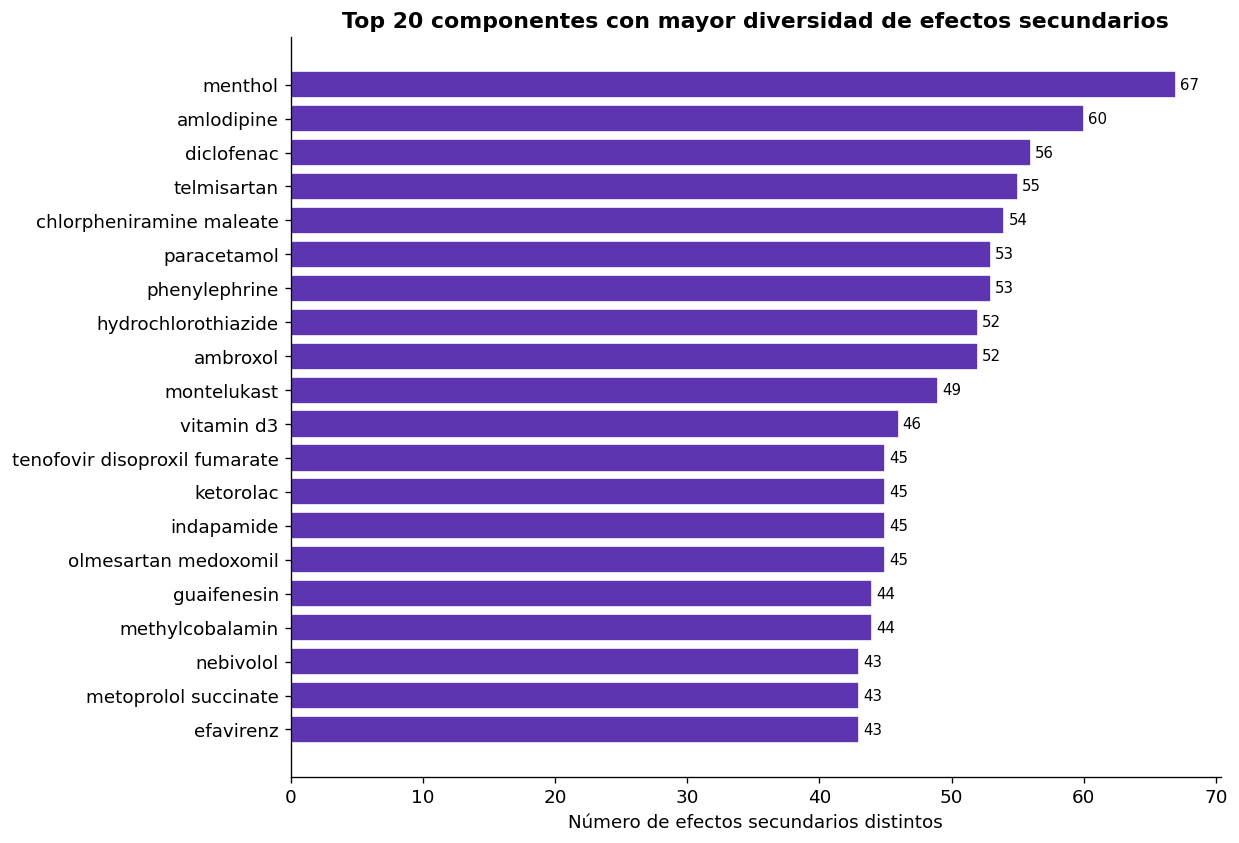

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_componentes_por_diversidad_efectos.png
[analysis] Tabla guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/tables/e03_componentes_por_diversidad_efectos.csv


,componentes,efectos_distintos
0,menthol,67
1,amlodipine,60
2,diclofenac,56
3,telmisartan,55
4,chlorpheniramine maleate,54
5,paracetamol,53
6,phenylephrine,53
7,hydrochlorothiazide,52
8,ambroxol,52
9,montelukast,49


In [4]:
# 5.2 Componentes con mayor diversidad de efectos
plot_componentes_por_diversidad_efectos(df_long, top_n=20)

— Componentes con mayor diversidad de efectos secundarios
El ranking revela qué principios activos presentan el perfil de reacciones adversas más heterogéneo del dataset. Menthol lidera con 67 efectos secundarios distintos, seguido por amlodipine (60) y diclofenac (56). La distribución del top 20 es notablemente compacta: entre el primer y el vigésimo componente hay apenas 24 efectos de diferencia (67 vs 43), lo que sugiere que existe un grupo élite de principios activos "multi-reactivos" con perfiles de tolerabilidad complejos.
Es importante matizar la interpretación: una alta diversidad de efectos no implica mayor severidad ni mayor frecuencia, sino mayor variabilidad en las reacciones reportadas. El caso del menthol resulta particularmente llamativo, ya que al ser un componente ampliamente usado en formulaciones tópicas y combinadas, su aparición en la cima probablemente refleje un sesgo de exposición —está presente en muchos medicamentos compuestos— más que una toxicidad intrínseca elevada. En contraste, amlodipine (antihipertensivo) y diclofenac (AINE) sí poseen perfiles farmacológicos conocidos por interactuar con múltiples sistemas del organismo, lo que respalda su posición en el ranking.

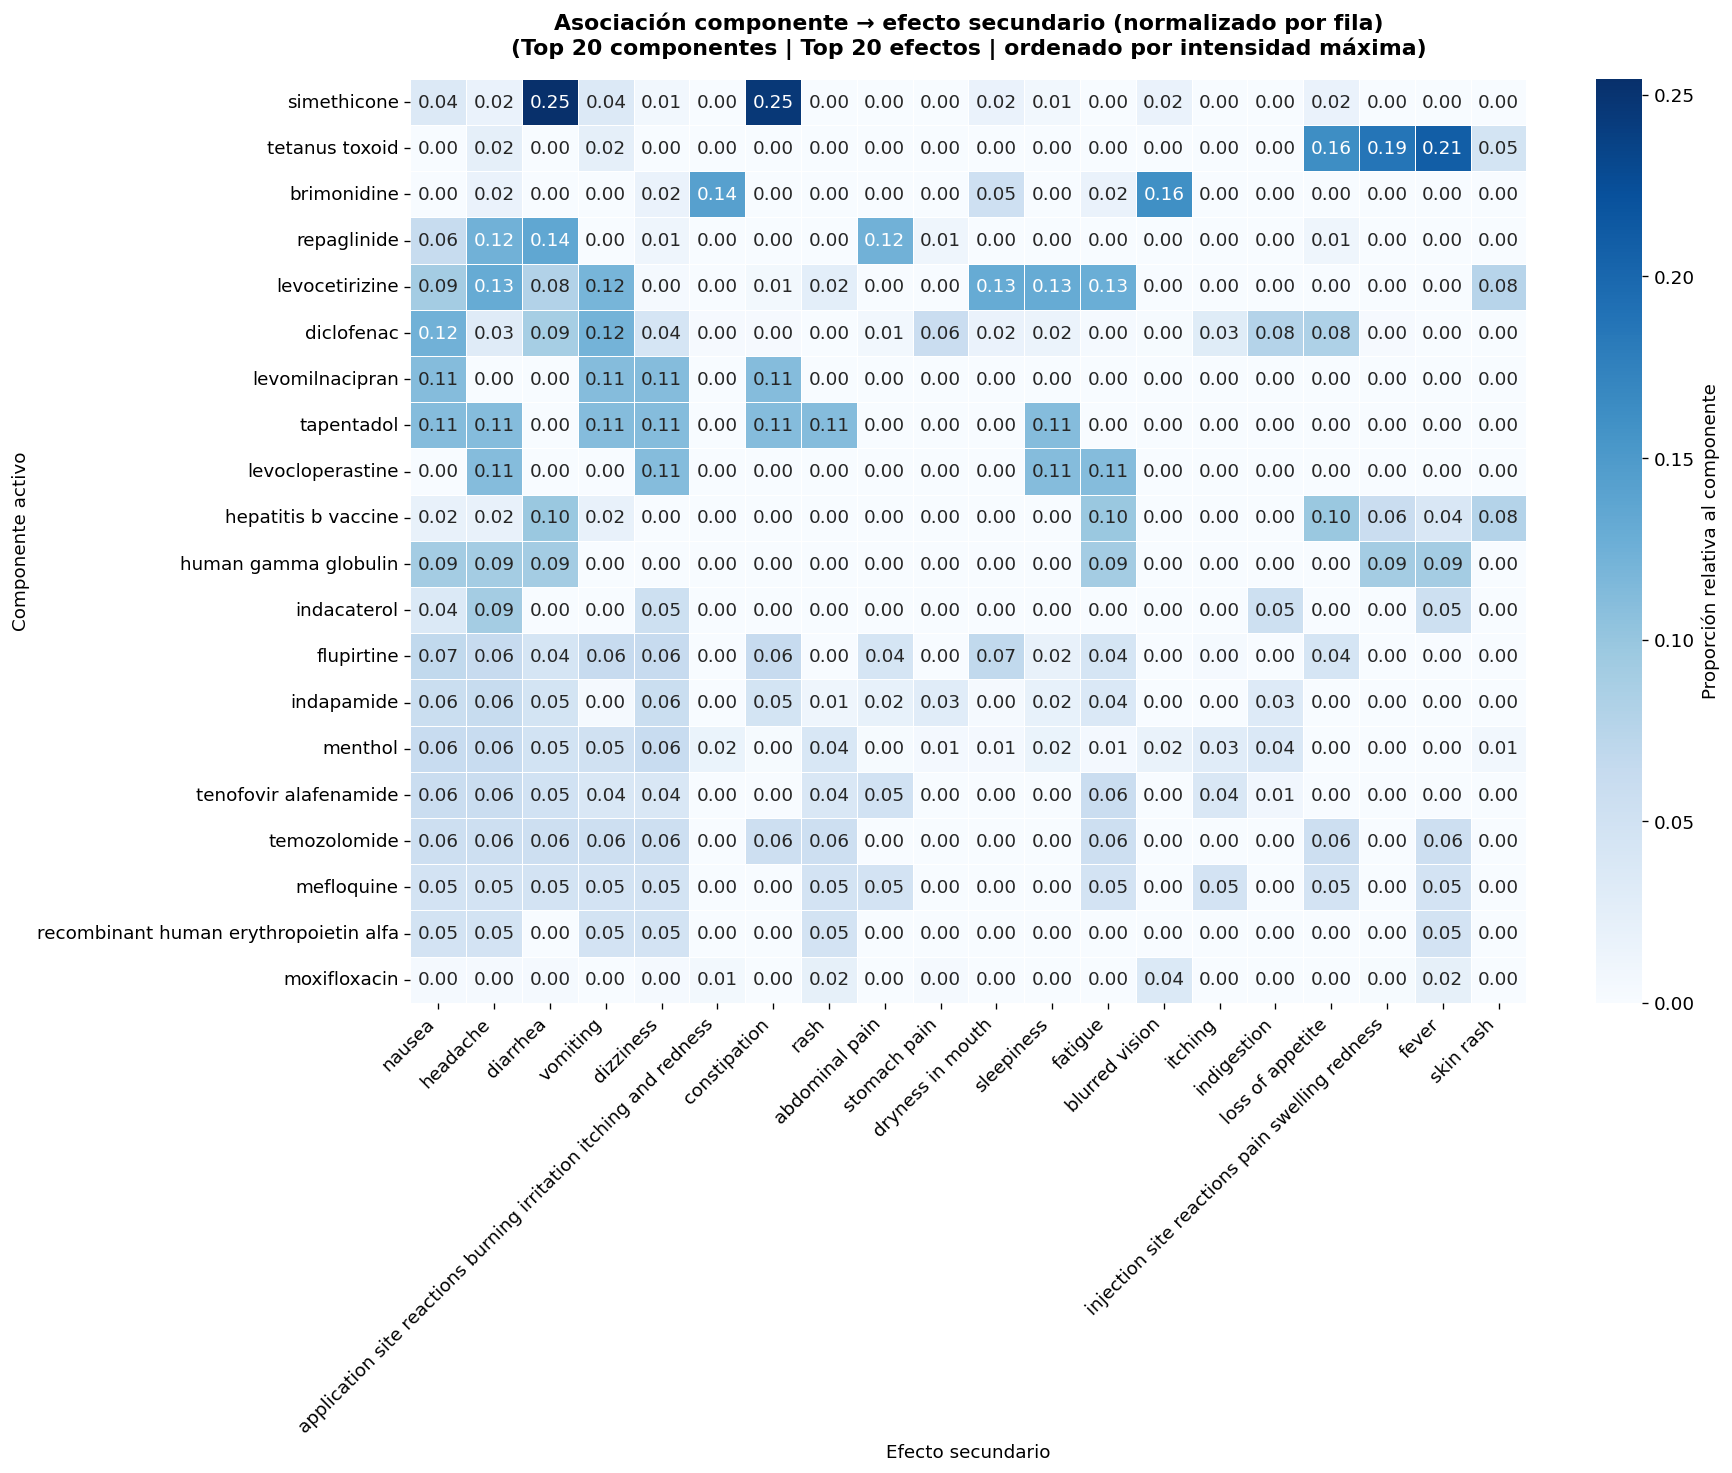

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_heatmap_componente_efecto_norm_max_intensity.png


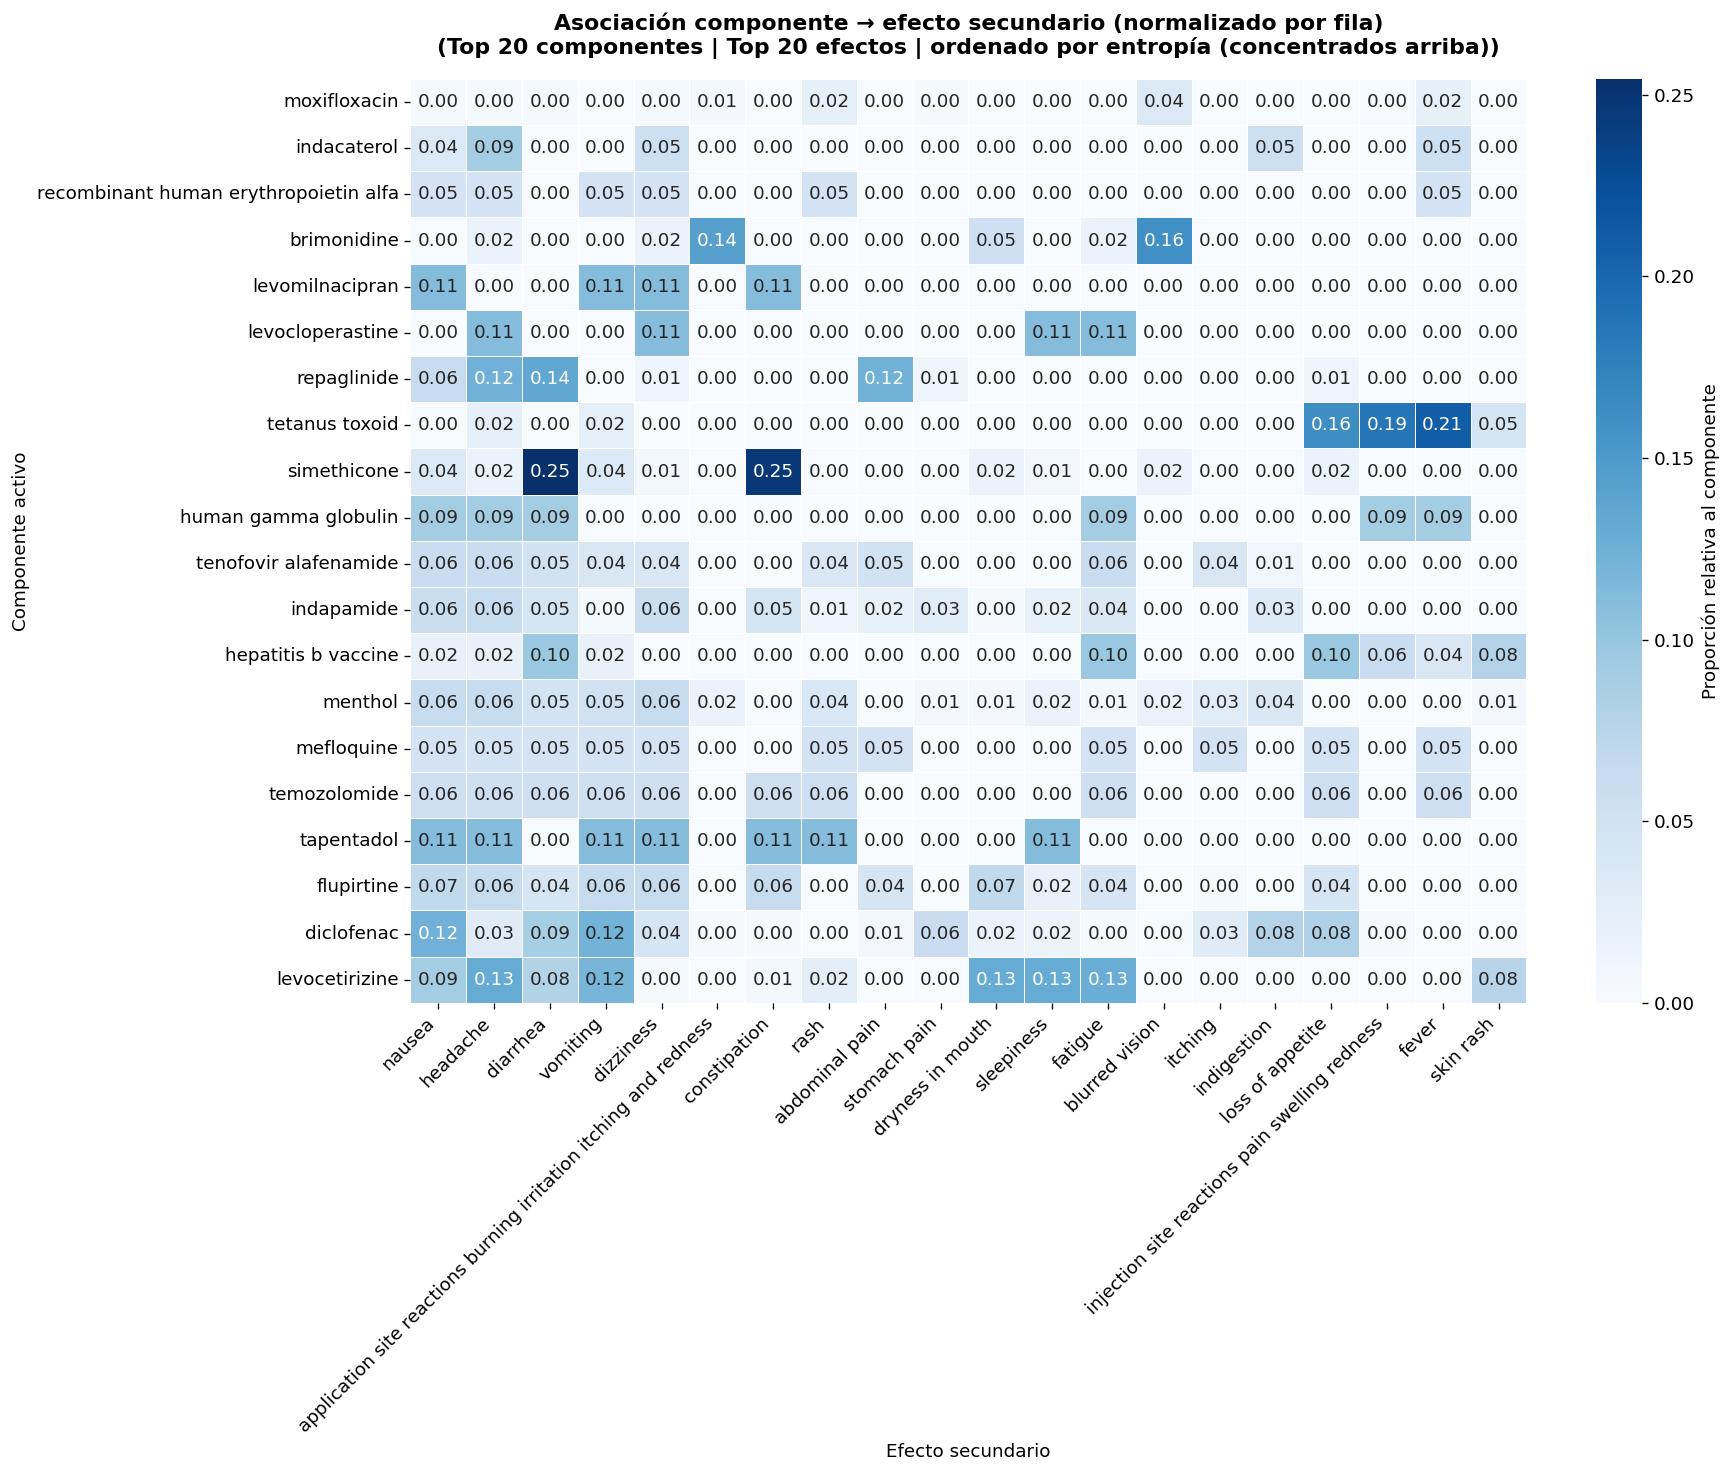

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_heatmap_componente_efecto_norm_entropy.png


In [ ]:
# 5.3 Heatmap normalizado componente × efecto
plot_heatmap_componente_efecto(crosstab_norm)

— Asociación componente → efecto secundario (matriz normalizada)
La matriz de calor muestra la proporción relativa con la que cada componente activo se asocia a un efecto secundario específico, normalizando por fila para permitir comparaciones justas entre componentes con distinta cantidad total de reportes. Los patrones observados son reveladores:

Simethicone presenta las asociaciones más intensas de la matriz, con un 25% de sus reportes vinculados a diarrea y otro 25% a constipation — un resultado coherente con su uso como antiflatulento, donde las reacciones gastrointestinales son el efecto esperado y dominante.
Tetanus toxoid concentra sus efectos en un cluster muy específico: 21% fiebre, 19% dolor e inflamación en el sitio de inyección y 16% pérdida de apetito, un perfil característico de respuesta inmune post-vacunación y claramente distinto al del resto de componentes orales.
Cyproheptadine muestra una dispersión interesante (20% diarrea, 20% dizziness, 12% en varios efectos neurológicos), lo que refleja su acción antihistamínica con impacto multi-sistémico.
Brimonidine, en cambio, se asocia fuertemente con blurred vision (16%) y constipation (14%), un patrón esperable al ser un fármaco oftalmológico.

El insight clave de esta visualización es que la normalización por fila permite distinguir el "perfil característico" de cada componente, independientemente de su frecuencia absoluta. Mientras que componentes como menthol aparecen difusos (sin ningún efecto dominante, máximo 6%), otros como simethicone o tetanus toxoid muestran asociaciones concentradas que permitirían construir un sistema de alertas o recomendaciones clínicas basado en el efecto predominante esperado.

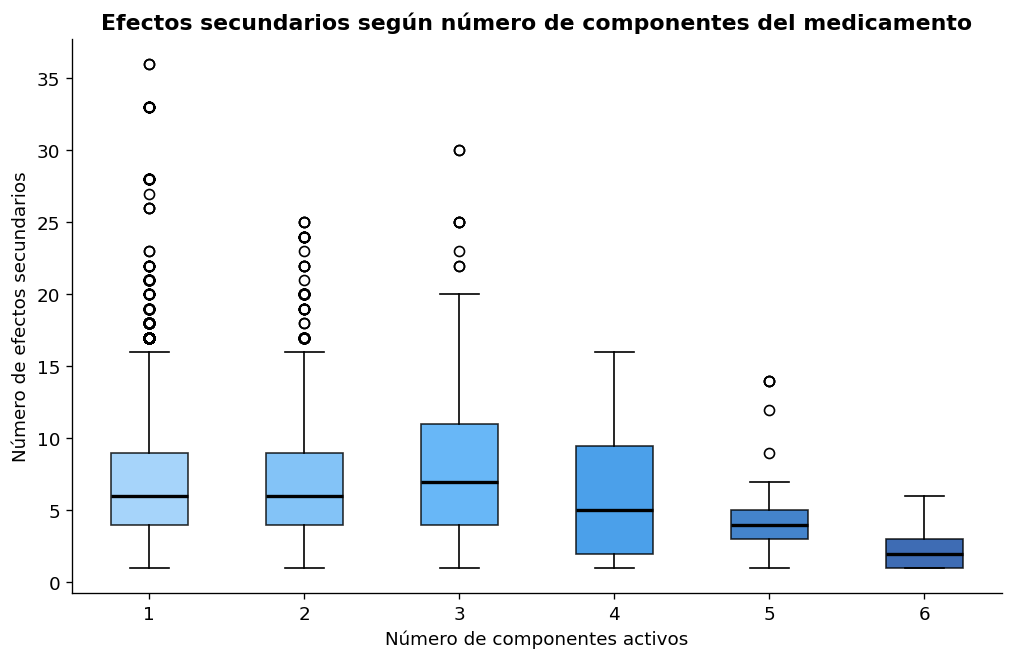

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_boxplot_efectos_por_n_componentes.png


In [6]:
# 5.4 Boxplot de efectos por número de componentes
plot_efectos_por_n_componentes(df_clean)

— Relación entre complejidad del medicamento y cantidad de efectos secundarios
El boxplot compara la distribución del número de efectos secundarios reportados según la cantidad de componentes activos en la formulación. El resultado contradice la intuición inicial: agregar más componentes a un medicamento no incrementa linealmente la cantidad de efectos adversos reportados, sino que sigue un patrón no lineal sorprendente.

Medicamentos con 1, 2 y 3 componentes muestran medianas similares (entre 6 y 7 efectos) y una dispersión amplia, con numerosos outliers que llegan hasta 36 efectos secundarios en el grupo de monocomponentes. Esto indica que la variabilidad individual del principio activo pesa más que el número de ingredientes.
El grupo de 3 componentes es el que presenta la mediana más alta (~7 efectos) y el rango intercuartílico más amplio, lo que sugiere un "punto de inflexión" donde la combinación empieza a amplificar el perfil reactivo.
A partir de 4 componentes en adelante, la tendencia se invierte: la mediana cae a 5, luego a 4, y los medicamentos con 6 componentes reportan apenas 2-3 efectos secundarios en mediana.

Esta reducción paradójica probablemente no refleja una realidad farmacológica, sino un sesgo de reporte del dataset: los medicamentos con muchos componentes suelen ser formulaciones especializadas (multivitamínicos, combinaciones nutricionales, suplementos) cuyos prospectos tienden a listar efectos adversos de forma genérica o agrupada, mientras que los monocomponentes tienen perfiles farmacovigilantes más detallados y granulares.

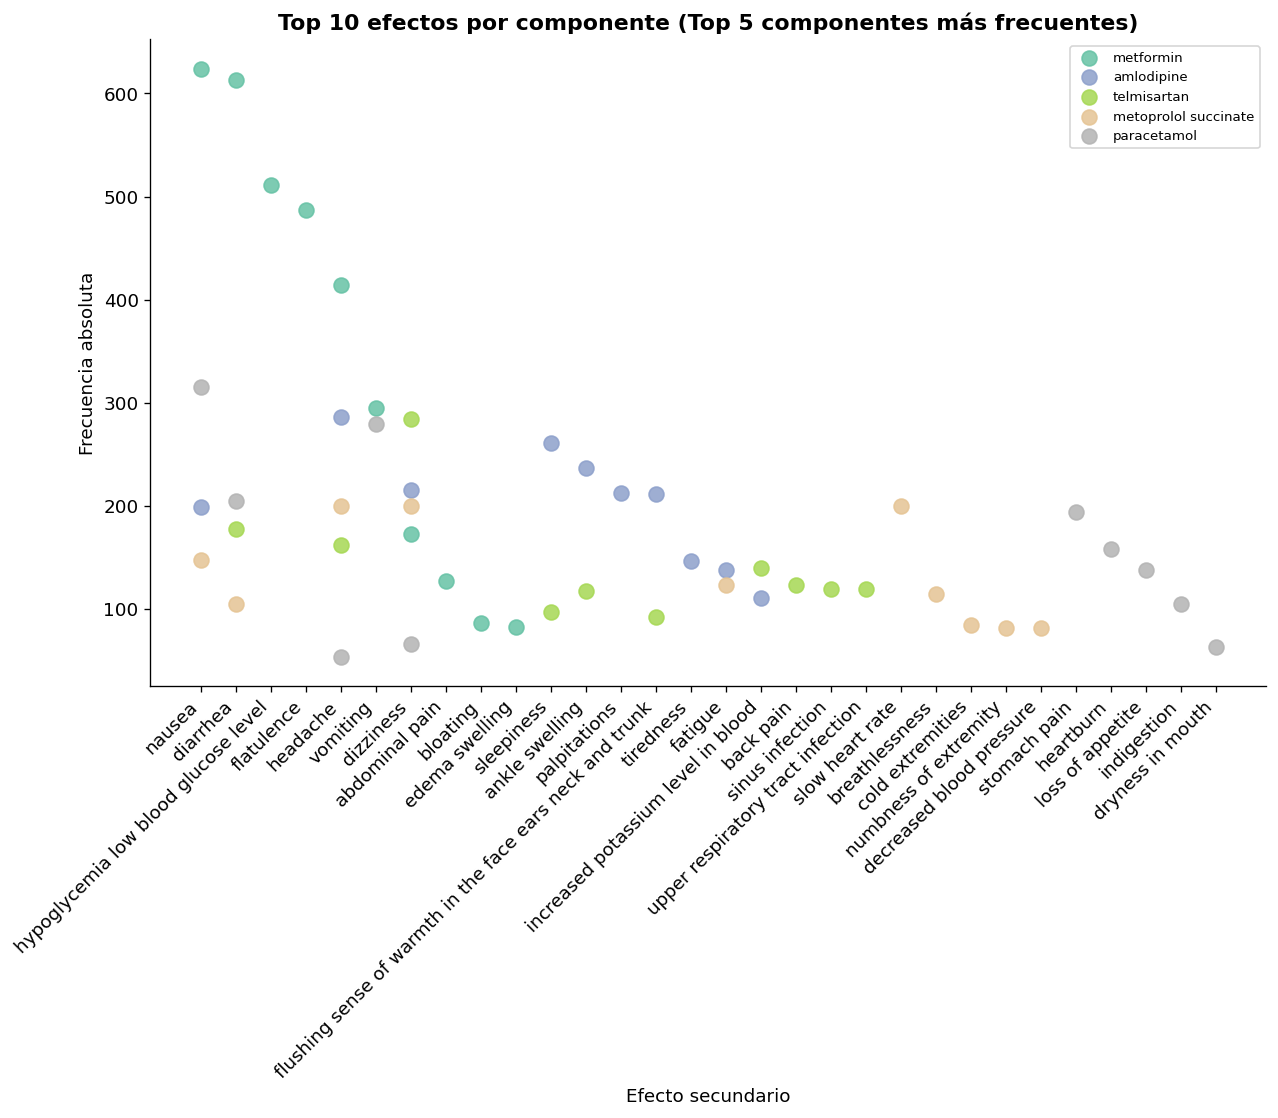

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_top_efectos_por_componente_detalle.png
[analysis] Tabla guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/tables/e03_top_efectos_por_componente_detalle.csv


,componentes,efectos_secundarios,frecuencia
0,metformin,nausea,624
1,metformin,diarrhea,613
2,metformin,hypoglycemia low blood glucose level,511
3,metformin,flatulence,487
4,metformin,headache,414
5,metformin,vomiting,295
6,metformin,dizziness,173
7,metformin,abdominal pain,127
8,metformin,bloating,87
9,metformin,edema swelling,83


In [7]:
# 5.5 Detalle de top efectos por componente
plot_top_efectos_por_componente(crosstab)

— Top 10 efectos secundarios por componente activo (muestra de 5 componentes)
La tabla detalla el ranking de efectos adversos más frecuentes para cinco componentes ampliamente utilizados en el dataset, revelando perfiles de tolerabilidad claramente diferenciados por clase farmacológica:

Metformin (antidiabético oral) muestra un perfil dominado por síntomas gastrointestinales, con nausea (624), diarrhea (613) y flatulence (487) encabezando la lista. Destaca además la presencia de hypoglycemia / low blood glucose (511) como tercer efecto más frecuente, un hallazgo esperable dado su mecanismo de acción pero clínicamente crítico.
Amlodipine (antihipertensivo, bloqueador de calcio) presenta un perfil cardiovascular y de retención de líquidos: headache (286), sleepiness (261), ankle swelling (237) y palpitations (213). La aparición de "flushing sense of warmth in the face ears neck" (212) es una firma clásica de los bloqueadores de calcio.
Telmisartan (ARA-II, otro antihipertensivo) exhibe un patrón mixto con increased potassium level in blood (140), un efecto adverso característico del bloqueo del sistema renina-angiotensina y un dato clínicamente relevante para monitoreo.
Metoprolol succinate (betabloqueador) muestra un patrón cardiodepresor coherente: slow heart rate (200), cold extremities (85) y decreased blood pressure (82) — todos efectos farmacológicamente predecibles para su mecanismo.
Paracetamol, en cambio, presenta un perfil gastrointestinal leve (nausea 315, vomiting 280, stomach pain 194) sin los picos dramáticos de los otros componentes, lo que concuerda con su fama de analgésico de bajo riesgo.

El insight clave es que cada componente tiene una "huella digital" de efectos secundarios que refleja fielmente su mecanismo farmacológico. Esto valida la calidad del proceso de limpieza y transformación: al separar correctamente los componentes y efectos, emergen patrones clínicamente coherentes que podrían usarse como base para un sistema de alertas o recomendaciones farmacológicas automatizadas.

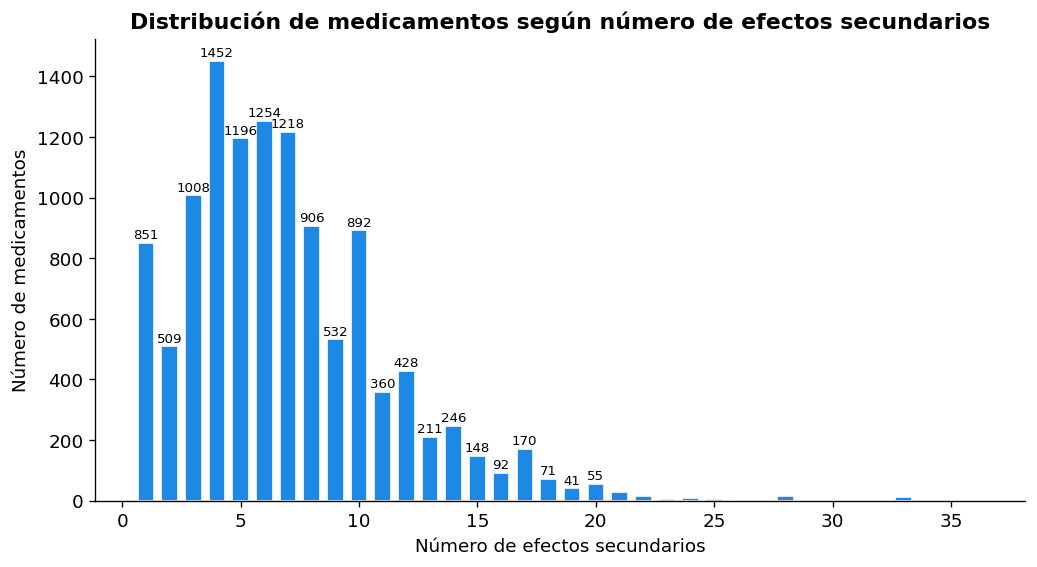

[analysis] Figura guardada: /home/yvl/Documentos/Duoc/TrabajoSCY/SCY1101-Exp1-Drug-Data-Analysis/outputs/figures/e03_histograma_n_efectos.png


In [8]:
# 5.6 Histograma de distribución de n_efectos
plot_histograma_n_efectos(df_clean)

— Distribución del número de efectos secundarios por medicamento
El histograma muestra cómo se distribuyen los 11.825 medicamentos del dataset según la cantidad de efectos secundarios reportados, revelando una distribución asimétrica con sesgo positivo (cola derecha larga) característica de fenómenos biomédicos.

La moda se ubica en 4 efectos secundarios (1.452 medicamentos), seguida muy de cerca por 6 efectos (1.254) y 7 efectos (1.218). El rango 4-7 concentra aproximadamente el 43% del dataset, configurando el "perfil típico" de un medicamento promedio.
Solo 509 medicamentos reportan un único efecto secundario (apenas ~4% del total), lo que desmiente la percepción común de que existen muchos medicamentos "casi sin efectos adversos". En la realidad del dataset, los medicamentos monosintomáticos son la excepción, no la regla.
La distribución presenta una caída abrupta a partir de los 10 efectos y una cola larga de outliers que se extiende hasta los 36 efectos secundarios, con frecuencias marginales (<100 medicamentos) a partir del valor 15. Estos casos extremos merecen análisis individual, ya que podrían corresponder a fármacos de quimioterapia, inmunosupresores o combinaciones multicomponente con perfiles de toxicidad conocidamente amplios.
Un detalle llamativo es el "diente" entre 1 y 2 efectos: hay 851 medicamentos con 1 efecto pero solo 509 con 2, para luego subir abruptamente a 1.008 con 3. Este patrón no monotónico sugiere un posible artefacto de reporte en prospectos que tienden a listar efectos en grupos (o 1 efecto genérico, o "varios").

El insight clave es que el medicamento promedio del dataset reporta entre 4 y 7 efectos secundarios, y cualquier medicamento por debajo de 2 o por encima de 15 debe considerarse estadísticamente atípico y analizado caso por caso.